In [6]:
from pathlib import Path
from urllib.request import urlretrieve
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score,
                             log_loss, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## 1. Load the supplied dataset

The dataset is downloaded from the course repository so the notebook runs for an examiner without a local ZIP file.

In [7]:
DATA_URL = ('https://raw.githubusercontent.com/WebClub-NITK/'
            'Intelligence-SIG-Recs-2026/main/'
            'mandatory-tasks/recommender-systems-cf-to-dlrm/datasets/'
            'dataset%20%28tasks%202%20and%203%29.zip')
zip_path = Path('dataset_tasks_2_3.zip')

if not zip_path.exists():
    urlretrieve(DATA_URL, zip_path)

with zipfile.ZipFile(zip_path) as archive:
    train = pd.read_csv(archive.open('train.csv'))
    test = pd.read_csv(archive.open('test.csv'))

print(train.shape)
print(test.shape)

train.head()

(40000, 40)
(10000, 40)


,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957


# 2. EDA


In [8]:
num_cols = [f'integer_feature_{i}' for i in range(1, 14)]
cat_cols = [f'categorical_feature_{i}' for i in range(1, 27)]

print('Click-through rate:', f"{train['label'].mean():.2%}")
print('Duplicate training rows:', train.duplicated().sum())

numeric_eda = pd.DataFrame({
    'missing_%': (train[num_cols].isna().mean() * 100).round(2),
    'minus_one_count': train[num_cols].eq(-1).sum(),
    'skew': train[num_cols].skew().round(2),
})
categorical_eda = pd.DataFrame({
    'missing_%': (train[cat_cols].isna().mean() * 100).round(2),
    'unique_categories': train[cat_cols].nunique(dropna=True),
})
display(numeric_eda)
display(categorical_eda.sort_values('unique_categories', ascending=False).head(10))

Click-through rate: 3.20%
Duplicate training rows: 0


,missing_%,minus_one_count,skew
integer_feature_1,18.49,0,108.24
integer_feature_2,8.69,0,5.08
integer_feature_3,24.54,0,7.57
integer_feature_4,39.99,0,25.50
integer_feature_5,38.53,0,11.85
integer_feature_6,8.82,0,11.58
integer_feature_7,3.03,0,32.37
integer_feature_8,0.00,2455,6.19
integer_feature_9,0.00,0,1.48
integer_feature_10,8.82,0,2.38


,missing_%,unique_categories
categorical_feature_20,4.05,13508
categorical_feature_1,4.05,13190
categorical_feature_22,4.05,12628
categorical_feature_10,4.05,11584
categorical_feature_21,4.05,9002
categorical_feature_12,0.00,7723
categorical_feature_11,4.05,5568
categorical_feature_23,36.36,5094
categorical_feature_3,0.00,4968
categorical_feature_5,0.00,4253


# 3. Preprocessing

In [9]:
SENTINEL = -1
MISSING = "__MISSING__"
MIN_COUNT = 10

# Keep the provided test set completely untouched until final evaluation.
X_train, X_val, y_train, y_val = train_test_split(
    train.drop(columns="label"),
    train["label"],
    test_size=0.20,
    random_state=SEED,
    stratify=train["label"],
)

# Numeric features:
# Treat -1 as missing, log-transform,
# then standardize using training statistics only.
train_numeric = X_train[num_cols].replace(SENTINEL, np.nan)
median = train_numeric.median()

scaler = StandardScaler().fit(
    np.log1p(train_numeric.fillna(median).clip(lower=0))
)

def scale_numeric(df):
    values = df[num_cols].replace(SENTINEL, np.nan)
    values = values.fillna(median).clip(lower=0)
    values = np.log1p(values)
    return scaler.transform(values).astype("float32")

X_train_num = scale_numeric(X_train)
X_val_num = scale_numeric(X_val)
X_test_num = scale_numeric(test)


# Categorical features:
# 0 = unknown or rare category
# 1 = missing category
# 2+ = frequent category observed in training
vocabs = {}

for col in cat_cols:
    values = X_train[col].fillna(MISSING).astype(str)
    counts = values.value_counts()

    frequent_values = counts[counts >= MIN_COUNT].index

    # Always retain missing as a separate signal.
    if MISSING not in frequent_values:
        frequent_values = frequent_values.insert(0, MISSING)

    vocabs[col] = frequent_values


def encode_categories(df):
    encoded_columns = []

    for col in cat_cols:
        values = df[col].fillna(MISSING).astype(str)

        # get_indexer returns -1 for unseen/rare values; +1 makes them 0.
        encoded = vocabs[col].get_indexer(values) + 1
        encoded_columns.append(encoded)

    return np.column_stack(encoded_columns).astype("int32")


X_train_cat = encode_categories(X_train)
X_val_cat = encode_categories(X_val)
X_test_cat = encode_categories(test)

# Embedding table size for each categorical feature.
cat_sizes = [len(vocabs[col]) + 1 for col in cat_cols]

print("Numeric matrices:", X_train_num.shape, X_val_num.shape, X_test_num.shape)
print("Categorical matrices:", X_train_cat.shape, X_val_cat.shape, X_test_cat.shape)
print("Largest embedding vocabulary:", max(cat_sizes))
print("Training click rate:", f"{y_train.mean():.2%}")
print("Validation click rate:", f"{y_val.mean():.2%}")

Numeric matrices: (32000, 13) (8000, 13) (10000, 13)
Categorical matrices: (32000, 26) (8000, 26) (10000, 26)
Largest embedding vocabulary: 645
Training click rate: 3.20%
Validation click rate: 3.20%


## 3. Shared input helper and vanilla baseline

The vanilla MLP is the Task 2 baseline: numeric inputs plus categorical embeddings are concatenated and passed through dense layers. It does not explicitly construct feature crosses.

In [10]:
def make_inputs(numeric_matrix, categorical_matrix):
    return {'numeric': numeric_matrix, **{
        column: categorical_matrix[:, index].reshape(-1, 1)
        for index, column in enumerate(cat_cols)
    }}

def build_feature_inputs():
    numeric_input = tf.keras.Input(shape=(len(num_cols),), name='numeric')
    inputs, categorical_vectors = {'numeric': numeric_input}, []
    for column in cat_cols:
        vocab_size = len(vocabs[column]) + 1
        embedding_dim = min(8, max(2, int(np.ceil(np.log2(vocab_size)))))
        feature_input = tf.keras.Input(shape=(1,), dtype='int32', name=column)
        embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)(feature_input)
        inputs[column] = feature_input
        categorical_vectors.append(tf.keras.layers.Flatten()(embedding))
    return inputs, numeric_input, categorical_vectors

def build_mlp(hidden_layers, dropout=0.0):
    inputs, numeric_input, categorical_vectors = build_feature_inputs()
    x = tf.keras.layers.Concatenate()([numeric_input, *categorical_vectors])
    for units in hidden_layers:
        x = tf.keras.layers.Dense(units, activation='relu')(x)
        if dropout > 0:
            x = tf.keras.layers.Dropout(dropout)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return compile_model(tf.keras.Model(inputs, output))

def compile_model(model):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(name='roc_auc'),
                           tf.keras.metrics.AUC(curve='PR', name='pr_auc'), 'accuracy'])
    return model

train_inputs = make_inputs(X_train_num, X_train_cat)
val_inputs = make_inputs(X_val_num, X_val_cat)
test_inputs = make_inputs(X_test_num, X_test_cat)

## 4. DLRM from scratch

The bottom MLP maps 13 dense inputs to a 16-dimensional vector. Each of the 26 categorical fields gets a 16-dimensional embedding. `DotInteraction` computes all lower-triangle pairwise dot products among those 27 vectors, including dense-to-categorical and categorical-to-categorical interactions. The dense vector and interaction values are then classified by the top MLP.

In [11]:
class DotInteraction(tf.keras.layers.Layer):
    """Return the lower-triangle pairwise dot products used by DLRM."""
    def __init__(self, n_features, **kwargs):
        super().__init__(**kwargs)
        rows, cols = np.tril_indices(n_features, k=-1)
        self.flat_indices = tf.constant(rows * n_features + cols, dtype=tf.int32)
        self.n_features = n_features

    def call(self, feature_vectors):
        dot_products = tf.matmul(feature_vectors, feature_vectors, transpose_b=True)
        flattened = tf.reshape(dot_products, (-1, self.n_features * self.n_features))
        return tf.gather(flattened, self.flat_indices, axis=1)

def build_dlrm(embed_dim=16, use_interactions=True):
    numeric_input = tf.keras.Input(shape=(len(num_cols),), name='numeric')
    inputs = {'numeric': numeric_input}

    # Bottom MLP: dense features become one embedding-sized vector.
    dense_vector = tf.keras.layers.Dense(64, activation='relu')(numeric_input)
    dense_vector = tf.keras.layers.Dense(embed_dim)(dense_vector)

    categorical_vectors = []
    for column in cat_cols:
        vocab_size = len(vocabs[column]) + 1
        feature_input = tf.keras.Input(shape=(1,), dtype='int32', name=column)
        embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)(feature_input)
        inputs[column] = feature_input
        categorical_vectors.append(tf.keras.layers.Flatten()(embedding))

    all_vectors = tf.keras.layers.Lambda(lambda vectors: tf.stack(vectors, axis=1))(
        [dense_vector, *categorical_vectors]
    )
    if use_interactions:
        interactions = DotInteraction(n_features=1 + len(cat_cols))(all_vectors)
        top_input = tf.keras.layers.Concatenate()([dense_vector, interactions])
    else:
        # Ablation: same features and MLPs, but no explicit dot-product crosses.
        top_input = tf.keras.layers.Flatten()(all_vectors)

    x = tf.keras.layers.Dense(128, activation='relu')(top_input)
    x = tf.keras.layers.Dropout(0.10)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return compile_model(tf.keras.Model(inputs, output))

## 5. Train the baseline, DLRM, and ablation

All candidates get the same early-stopping policy. We select the final model only with validation ROC-AUC; test data is not used for selection. The ablation removes the DLRM dot-product interaction block while retaining the same bottom embeddings and top MLP.

In [12]:
def train_candidate(model):
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_roc_auc', mode='max', patience=3, restore_best_weights=True
    )
    started = time.perf_counter()
    history = model.fit(train_inputs, y_train, validation_data=(val_inputs, y_val),
                        epochs=20, batch_size=512, verbose=0, callbacks=[early_stop])
    seconds = time.perf_counter() - started
    return history.history, seconds

# This is the same small architecture search used in Task 2.
architectures = {'small [32]': ([32], 0.0),
                 'medium [64, 32]': ([64, 32], 0.10),
                 'wide [128, 64]': ([128, 64], 0.20)}
vanilla_models, vanilla_histories, vanilla_auc = {}, {}, {}
for label, (layers, dropout) in architectures.items():
    model = build_mlp(layers, dropout)
    history, _ = train_candidate(model)
    vanilla_models[label] = model
    vanilla_histories[label] = history
    vanilla_auc[label] = max(history['val_roc_auc'])
    print(f"Vanilla {label}: validation ROC-AUC = {vanilla_auc[label]:.4f}")

best_vanilla_name = max(vanilla_auc, key=vanilla_auc.get)
best_vanilla = vanilla_models[best_vanilla_name]
baseline_name = f'Vanilla MLP ({best_vanilla_name})'

models = {baseline_name: best_vanilla}
histories = {baseline_name: vanilla_histories[best_vanilla_name]}
train_cost = {baseline_name: {'seconds': np.nan, 'parameters': best_vanilla.count_params(),
                              'best_val_auc': vanilla_auc[best_vanilla_name]}}

for name, builder in {'DLRM (dot interactions)': lambda: build_dlrm(16, True),
                      'DLRM ablation (no interactions)': lambda: build_dlrm(16, False)}.items():
    model = builder()
    history, seconds = train_candidate(model)
    models[name] = model
    histories[name] = history
    train_cost[name] = {'seconds': seconds, 'parameters': model.count_params(),
                        'best_val_auc': max(history['val_roc_auc'])}
    print(f"{name}: validation ROC-AUC = {train_cost[name]['best_val_auc']:.4f}, {seconds:.1f}s")


Vanilla small [32]: validation ROC-AUC = 0.7334
Vanilla medium [64, 32]: validation ROC-AUC = 0.7298
Vanilla wide [128, 64]: validation ROC-AUC = 0.7263
DLRM (dot interactions): validation ROC-AUC = 0.7148, 18.7s
DLRM ablation (no interactions): validation ROC-AUC = 0.7380, 15.1s


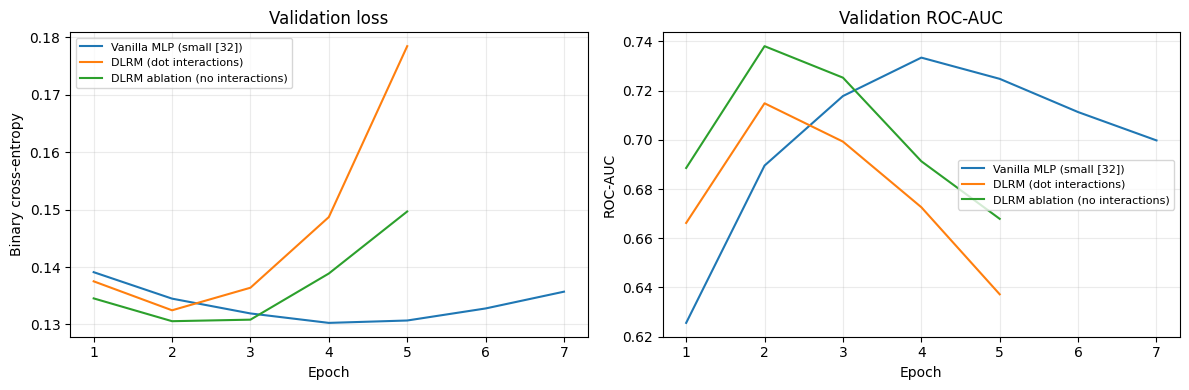

,Model,Parameters,Estimated weights (MiB),Training seconds,Best validation ROC-AUC
2,DLRM ablation (no interactions),148961,0.57,15.1,0.7380
0,Vanilla MLP (small [32]),47155,0.18,nan,0.7334
1,DLRM (dot interactions),140641,0.54,18.7,0.7148


Memory note: the table estimates only float32 model weights. During training, optimizer states, gradients, batches, and activations require additional memory. In large recommenders, embedding tables usually dominate memory.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in histories.items():
    epoch = range(1, len(history['loss']) + 1)
    axes[0].plot(epoch, history['val_loss'], label=name)
    axes[1].plot(epoch, history['val_roc_auc'], label=name)
axes[0].set(title='Validation loss', xlabel='Epoch', ylabel='Binary cross-entropy')
axes[1].set(title='Validation ROC-AUC', xlabel='Epoch', ylabel='ROC-AUC')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
plt.tight_layout(); plt.show()

cost_table = pd.DataFrame([
    {'Model': name, 'Parameters': info['parameters'],
     'Estimated weights (MiB)': info['parameters'] * 4 / 1024**2,
     'Training seconds': info['seconds'], 'Best validation ROC-AUC': info['best_val_auc']}
    for name, info in train_cost.items()
]).sort_values('Best validation ROC-AUC', ascending=False)
display(cost_table.style.format({'Estimated weights (MiB)': '{:.2f}',
                                  'Training seconds': '{:.1f}',
                                  'Best validation ROC-AUC': '{:.4f}'}))

print('Memory note: the table estimates only float32 model weights. During training, optimizer states, gradients, batches, and activations require additional memory. In large recommenders, embedding tables usually dominate memory.')

## 6. Final test metrics, calibration, and comparison

The threshold for F1 is chosen separately for each candidate using validation predictions only. The final selected model is the validation ROC-AUC winner. The table still shows all test rows, making the DLRM ablation and Task 2 baseline comparison transparent.

In [ ]:
if 'label' not in test.columns:
    raise ValueError('test.csv needs a label column to calculate final metrics.')

selected_name = max(train_cost, key=lambda name: train_cost[name]['best_val_auc'])
print('Selected from validation ROC-AUC:', selected_name)

y_test = test['label'].to_numpy()
thresholds = np.linspace(0.05, 0.95, 181)
rows, test_probabilities = [], {}

for name, model in models.items():
    validation_probability = model.predict(val_inputs, verbose=0).ravel()
    threshold = max(thresholds, key=lambda value: f1_score(y_val, validation_probability >= value))
    probability = model.predict(test_inputs, verbose=0).ravel()
    prediction = (probability >= threshold).astype(int)
    test_probabilities[name] = probability
    rows.append({
        'Model': name,
        'Validation ROC-AUC': train_cost[name]['best_val_auc'],
        'ROC-AUC': roc_auc_score(y_test, probability),
        'PR-AUC': average_precision_score(y_test, probability),
        'Log loss': log_loss(y_test, probability),
        'Accuracy': accuracy_score(y_test, prediction),
        'F1': f1_score(y_test, prediction),
        'Precision': precision_score(y_test, prediction, zero_division=0),
        'Recall': recall_score(y_test, prediction, zero_division=0),
        'Threshold': threshold,
    })

metrics = pd.DataFrame(rows).sort_values('Validation ROC-AUC', ascending=False).reset_index(drop=True)
display(metrics.style.format({column: '{:.4f}' for column in metrics.columns if column != 'Model'})
        .highlight_max(subset=['Validation ROC-AUC', 'ROC-AUC', 'PR-AUC', 'F1'], color='#C6EFCE'))

selected_probability = test_probabilities[selected_name]
fraction_positive, mean_predicted = calibration_curve(y_test, selected_probability, n_bins=10, strategy='quantile')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[0].plot(mean_predicted, fraction_positive, marker='o', label=selected_name)
axes[0].set(title='Reliability plot', xlabel='Mean predicted probability', ylabel='Observed click frequency')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)
for name, probability in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    auc = metrics.loc[metrics['Model'] == name, 'ROC-AUC'].iloc[0]
    axes[1].plot(fpr, tpr, label=f'{name}: {auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set(title='Test ROC curves', xlabel='False positive rate', ylabel='True positive rate')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()